In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# CONFIG
DATA_PATH = "../data/Sleep_health_and_lifestyle_dataset.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG
DATA_PATH = "../data/Sleep_health_and_lifestyle_dataset.csv"

# LOAD
df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.dtypes)
print(df.head())

df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

low_freq = ['Software Engineer', 'Scientist', 'Sales Representative', 'Manager']
df['Occupation'] = df['Occupation'].replace(low_freq, 'Other')

print(df['Sleep Disorder'].value_counts())
print(df['BMI Category'].value_counts())
print(df['Occupation'].value_counts())

# SPLIT BLOOD PRESSURE
df[['BP Systolic', 'BP Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df = df.drop(columns=['Blood Pressure'])

print(df[['BP Systolic', 'BP Diastolic']].describe())

df = df.drop(columns=['Person ID'])

print(df.shape)
print(df.columns.tolist())

df['Pulse Pressure'] = df['BP Systolic'] - df['BP Diastolic']
df = df.drop(columns=['BP Systolic', 'BP Diastolic'])

print(df['Pulse Pressure'].describe())
print(df.shape)

BMI_ORDER = {'Normal': 0, 'Overweight': 1, 'Obese': 2}
df['BMI Category'] = df['BMI Category'].map(BMI_ORDER)

df = pd.get_dummies(df, columns=['Gender', 'Occupation'], drop_first=True)

BOOL_COLS = df.select_dtypes(include='bool').columns
df[BOOL_COLS] = df[BOOL_COLS].astype(int)

print(df.shape)
print(df.dtypes)

TARGET_ORDER = {'None': 0, 'Insomnia': 1, 'Sleep Apnea': 2}
df['Sleep Disorder'] = df['Sleep Disorder'].map(TARGET_ORDER)

print(df['Sleep Disorder'].value_counts().sort_index())
print(df.dtypes.unique())

(374, 13)
Person ID                    int64
Gender                         str
Age                          int64
Occupation                     str
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                   str
Blood Pressure                 str
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder                 str
dtype: object
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42     

In [6]:
# TRAIN/TEST SPLIT
X = df.drop(columns=['Sleep Disorder'])
y = df['Sleep Disorder']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest class distribution:\n{y_test.value_counts().sort_index()}")

Train: (299, 17), Test: (75, 17)

Train class distribution:
Sleep Disorder
0    175
1     62
2     62
Name: count, dtype: int64

Test class distribution:
Sleep Disorder
0    44
1    15
2    16
Name: count, dtype: int64


In [7]:
# FEATURE SCALING
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
print(f"X_train_scaled mean: {X_train_scaled.mean(axis=0).round(2)}")
print(f"X_train_scaled std: {X_train_scaled.std(axis=0).round(2)}")

X_train_scaled mean: [ 0.  0. -0. -0. -0.  0.  0. -0.  0.  0. -0.  0. -0. -0. -0.  0. -0.]
X_train_scaled std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [9]:
# BASELINE MODEL
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

print("Baseline (Most Frequent) Classification Report:")
print(classification_report(y_test, y_pred_dummy,
      target_names=['None', 'Insomnia', 'Sleep Apnea']))

Baseline (Most Frequent) Classification Report:
              precision    recall  f1-score   support

        None       0.59      1.00      0.74        44
    Insomnia       0.00      0.00      0.00        15
 Sleep Apnea       0.00      0.00      0.00        16

    accuracy                           0.59        75
   macro avg       0.20      0.33      0.25        75
weighted avg       0.34      0.59      0.43        75



c:\Users\ivanz\OneDrive\Desktop\sleep-health-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ivanz\OneDrive\Desktop\sleep-health-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ivanz\OneDrive\Desktop\sleep-health-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [10]:
# LOGISTIC REGRESSION
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['None', 'Insomnia', 'Sleep Apnea']))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

        None       1.00      0.91      0.95        44
    Insomnia       0.92      0.80      0.86        15
 Sleep Apnea       0.68      0.94      0.79        16

    accuracy                           0.89        75
   macro avg       0.87      0.88      0.87        75
weighted avg       0.92      0.89      0.90        75



In [11]:
# RANDOM FOREST
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['None', 'Insomnia', 'Sleep Apnea']))

Random Forest Classification Report:
              precision    recall  f1-score   support

        None       1.00      0.95      0.98        44
    Insomnia       0.92      0.80      0.86        15
 Sleep Apnea       0.75      0.94      0.83        16

    accuracy                           0.92        75
   macro avg       0.89      0.90      0.89        75
weighted avg       0.93      0.92      0.92        75



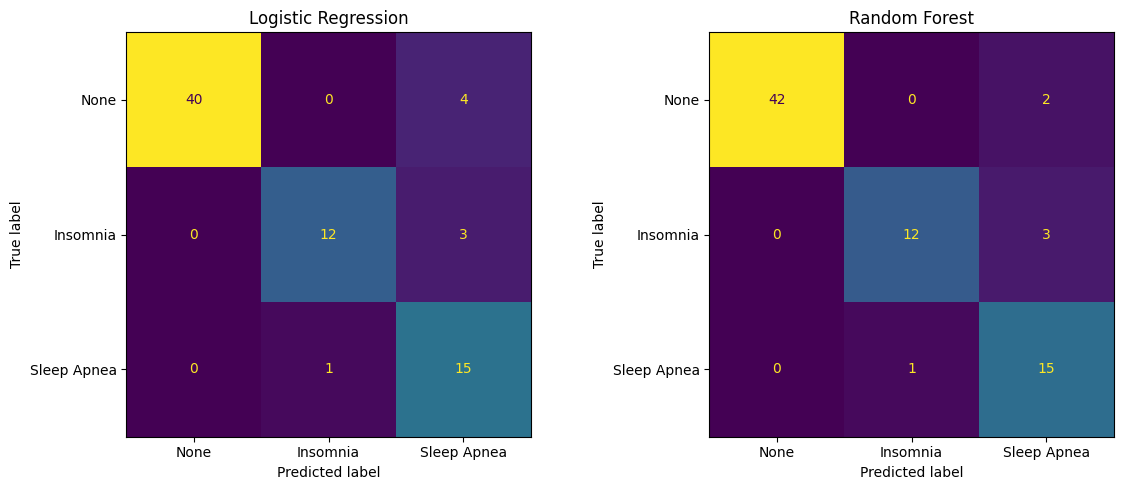

In [12]:
# CONFUSION MATRICES
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_rf],
                              ['Logistic Regression', 'Random Forest']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['None', 'Insomnia', 'Sleep Apnea'],
        ax=ax, colorbar=False
    )
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../notebooks/confusion_matrices.png', dpi=150)
plt.show()

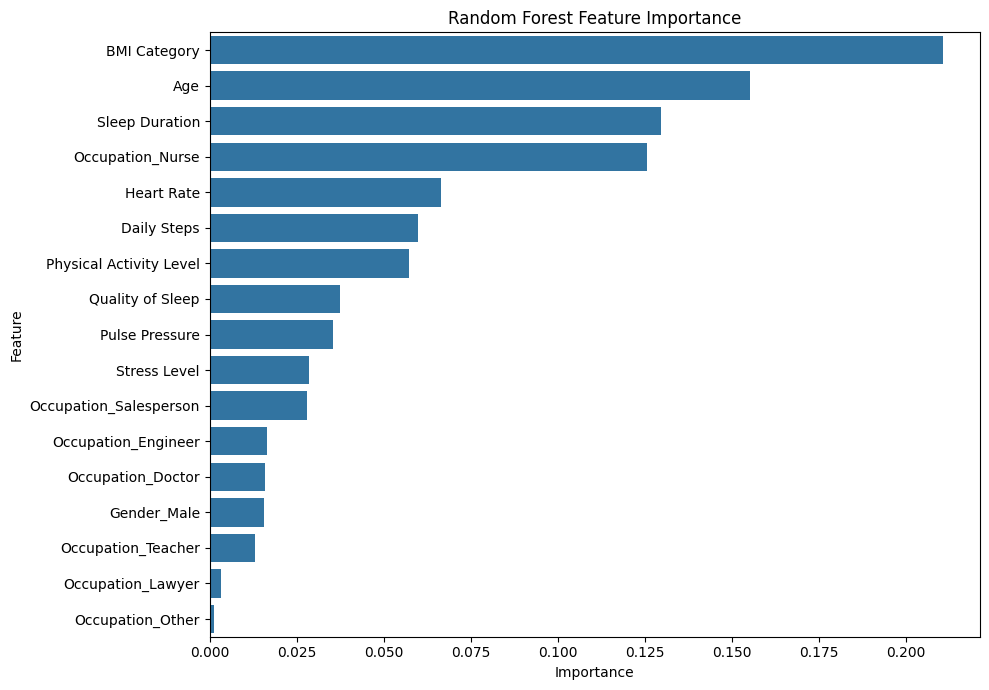

                Feature  Importance
           BMI Category    0.210806
                    Age    0.155297
         Sleep Duration    0.129814
       Occupation_Nurse    0.125766
             Heart Rate    0.066443
            Daily Steps    0.059788
Physical Activity Level    0.057241
       Quality of Sleep    0.037482
         Pulse Pressure    0.035495
           Stress Level    0.028544
 Occupation_Salesperson    0.028040
    Occupation_Engineer    0.016464
      Occupation_Doctor    0.015889
            Gender_Male    0.015526
     Occupation_Teacher    0.012964
      Occupation_Lawyer    0.003136
       Occupation_Other    0.001307


In [13]:
# FEATURE IMPORTANCE
feature_names = X.columns.tolist()
importances = rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('../notebooks/feature_importance.png', dpi=150)
plt.show()

print(importance_df.to_string(index=False))